In [ ]:
import os
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry

from torch.utils.data import DataLoader
from pytorch_ood.detector import Mahalanobis
from pytorch_ood.utils import OODMetrics

# Make the project root importable so `utils.ood_datasets` can be found.
current = Path.cwd().parent.parent
for parent in [current] + list(current.parents):
    if (parent / "utils").exists():
        PROJECT_ROOT = parent
        break
else:
    raise RuntimeError("Could not find project root containing 'utils' folder")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from utils.ood_datasets import (
    MRIDataset,
    ComposeImageTransforms,
    EnsureChannels,
    ResizeImageOrVolume,
)

In [3]:
device = "cuda:1"
ckpt = "../work_dir/MedSAM/medsam_vit_b.pth"  
model = sam_model_registry["vit_b"](checkpoint=ckpt).to(device).eval()

In [4]:
datasets_path = "../../datasets/"
prep_datasets = "/prep_datasets"
ID_path = datasets_path + prep_datasets + "/MnM_splits/vendor_split_ed_es/Philips"

# Model-specific input formatting for MedSAM:
# - convert grayscale MRI slices to 3 channels
# - resize to the encoder input size
medsam_model_transform = ComposeImageTransforms([
    EnsureChannels(3),
    ResizeImageOrVolume((1024, 1024)),
])

# ID data using the refactored MRI dataset.
# ROI extraction is intentionally ignored here; full images are used.
id_dataset = MRIDataset(
    root=ID_path,
    output_mode="2d",
    slice_strategy="middle_3",
    slice_axis=2,
    frame_selector=0,
    channels=1,
    label=0,
    return_metadata=False,
    model_transform=medsam_model_transform,
)

id_loader = DataLoader(id_dataset, batch_size=4, shuffle=False, num_workers=0)

In [5]:
OOD_path = datasets_path + prep_datasets + "/MnM_splits/vendor_split_ed_es/GE"

ood_dataset = MRIDataset(
    root=OOD_path,
    output_mode="2d",
    slice_strategy="middle_3",
    slice_axis=2,
    frame_selector=0,
    channels=1,
    label=-1,
    return_metadata=False,
    model_transform=medsam_model_transform,
)

ood_loader = DataLoader(ood_dataset, batch_size=4, shuffle=False, num_workers=0)

In [6]:
print(len(id_dataset))

750


In [7]:
id_batch = next(iter(id_loader))
ood_batch = next(iter(ood_loader))

imgs = id_batch["image"]
labels = id_batch["label"]
imgs_ood = ood_batch["image"]
labels_ood = ood_batch["label"]

print(imgs.shape)

torch.Size([4, 3, 1024, 1024])


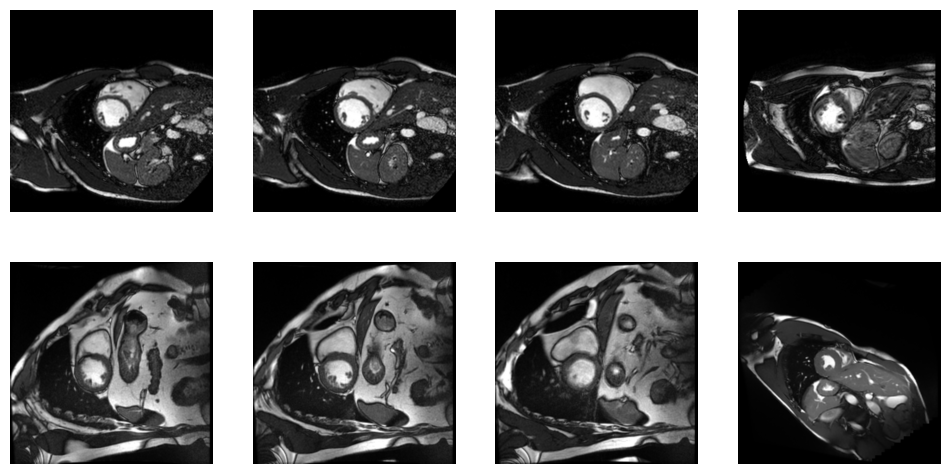

In [8]:
id_batch = next(iter(id_loader))
ood_batch = next(iter(ood_loader))

imgs = id_batch["image"]
imgs_ood = ood_batch["image"]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(4):
    # ID images (row 0)
    img = imgs[i].permute(1, 2, 0).cpu().numpy()
    axes[0, i].imshow(img)
    axes[0, i].axis("off")

    # OOD images (row 1)
    img_ood = imgs_ood[i].permute(1, 2, 0).cpu().numpy()
    axes[1, i].imshow(img_ood)
    axes[1, i].axis("off")

plt.show()

In [9]:
# Stage 1: Create DNN
model = sam_model_registry["vit_b"](checkpoint=ckpt).to(device).eval()

# Pass ID data through encoder and fit Mahalanobis distance metric
feats_list_id = []
labels_list_id = []

model.eval()

with torch.no_grad():
    for batch in id_loader:
        imgs = batch["image"].to(device)
        y = batch["label"].to(device)

        z = model.image_encoder(imgs)              # [B, C, H, W] feature maps
        z = z.mean(dim=(2, 3))                     # [B, C] global average pool

        feats_list_id.append(z)
        labels_list_id.append(y)

Z_id = torch.cat(feats_list_id, dim=0)
Y_id = torch.cat(labels_list_id, dim=0)

detector = Mahalanobis(model=None)
detector.fit_features(Z_id, Y_id)

No device given. Will use 'cuda:1'.


In [21]:
path_to_save="../../feature_space_inspection/"

torch.save(Z_id.detach().cpu(), path_to_save + "medSAM_MnM")

In [9]:
# Predict on OOD dataset
feats_list = []

with torch.no_grad():
    for batch in ood_loader:
        imgs = batch["image"].to(device)
        z = model.image_encoder(imgs)
        z = z.mean(dim=(2, 3))
        feats_list.append(z)

Z_ood = torch.cat(feats_list, dim=0)


torch.save(Z_ood.detach().cpu(), path_to_save + "medSAM_MnM_ood")

scores_id = detector.predict_features(Z_id)
scores_ood = detector.predict_features(Z_ood)

NameError: name 'path_to_save' is not defined

In [10]:
path_to_save="../../feature_space_inspection/"
torch.save(Z_ood.detach().cpu(), path_to_save + "medSAM_MnM_ood")

/tmp/ipykernel_293/653928018.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-((x - mu)**2) / (2 * sigma**2))


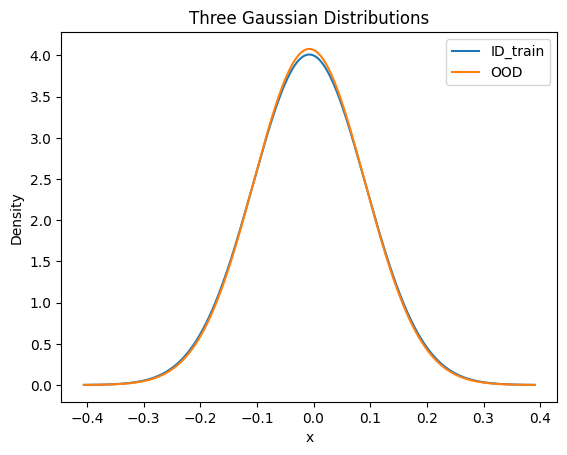

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Example means and stds (replace with yours)
mu1, sigma1 = Z_id.detach().cpu().mean(), Z_id.detach().cpu().std()
mu2, sigma2 = Z_ood.detach().cpu().mean(), Z_ood.detach().cpu().std()

# Shared x-axis range (important!)
x_min = min(mu1 - 4*sigma1, mu2 - 4*sigma2)
x_max = max(mu1 + 4*sigma1, mu2 + 4*sigma2)
x = np.linspace(x_min, x_max, 1000)

def gaussian(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-((x - mu)**2) / (2 * sigma**2))

# Compute curves
y1 = gaussian(x, mu1, sigma1)
y2 = gaussian(x, mu2, sigma2)

# Plot
plt.plot(x, y1, label="ID_train")
plt.plot(x, y2, label="OOD")


plt.title("Three Gaussian Distributions")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()

In [11]:
# 1) Make label tensors (same length as scores)
y_id  = torch.zeros(len(scores_id), dtype=torch.long)        # ID label = 0
y_ood = -torch.ones(len(scores_ood), dtype=torch.long)       # OOD label = -1

# 2) Concatenate
scores = torch.cat([scores_id.detach().cpu(), scores_ood.detach().cpu()], dim=0)
y_true = torch.cat([y_id, y_ood], dim=0)

# 3) Compute metrics
metrics = OODMetrics()
metrics.update(scores, y_true)
result = metrics.compute()

print(result)

{'AUROC': 0.9932355880737305, 'AUTC': 0.3345922529697418, 'AUPR-IN': 0.9934699535369873, 'AUPR-OUT': 0.9941465854644775, 'FPR95TPR': 0.0}


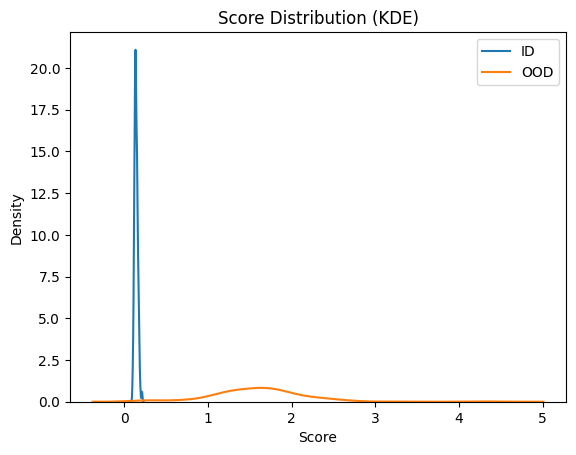

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

scores_id_np = scores_id.detach().cpu().numpy()
scores_ood_np = scores_ood.detach().cpu().numpy()

sns.kdeplot(scores_id_np, label="ID", fill=False)
sns.kdeplot(scores_ood_np, label="OOD", fill=False)

plt.title("Score Distribution (KDE)")
plt.xlabel("Score")
plt.ylabel("Density")
plt.legend()
plt.show()


In [13]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# -----------------------------
# 1) Convert features to numpy
# -----------------------------
X_id = Z_id.detach().cpu().numpy()      # [N_id, C]
y_id = Y_id.detach().cpu().numpy()      # [N_id]

X_ood = Z_ood.detach().cpu().numpy()    # [N_ood, C]

# If you have OOD labels, use them here.
# Example:
y_ood = y_ood.detach().cpu().numpy()

# If you do NOT have OOD labels, assign a placeholder label.
# This is only for plotting/coloring if needed.
# y_ood = np.full(shape=(X_ood.shape[0],), fill_value=-1)

# -----------------------------------------
# 2) Concatenate so t-SNE sees both together
# -----------------------------------------
X_all = np.concatenate([X_id, X_ood], axis=0)
y_all = np.concatenate([y_id, y_ood], axis=0)

# Keep track of domain: ID vs OOD
domain_all = np.concatenate([
    np.zeros(X_id.shape[0], dtype=int),   # 0 = ID
    np.ones(X_ood.shape[0], dtype=int),   # 1 = OOD
])

# -----------------------------
# 3) Optional PCA before t-SNE
# -----------------------------
n_pca = min(50, X_all.shape[1], X_all.shape[0])
X_reduced = PCA(n_components=n_pca, random_state=42).fit_transform(X_all)

# -----------------------------
# 4) Run t-SNE
# -----------------------------
X_tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42,
).fit_transform(X_reduced)

# Split back
X_tsne_id = X_tsne[domain_all == 0]
X_tsne_ood = X_tsne[domain_all == 1]

y_id_plot = y_all[domain_all == 0]
y_ood_plot = y_all[domain_all == 1]

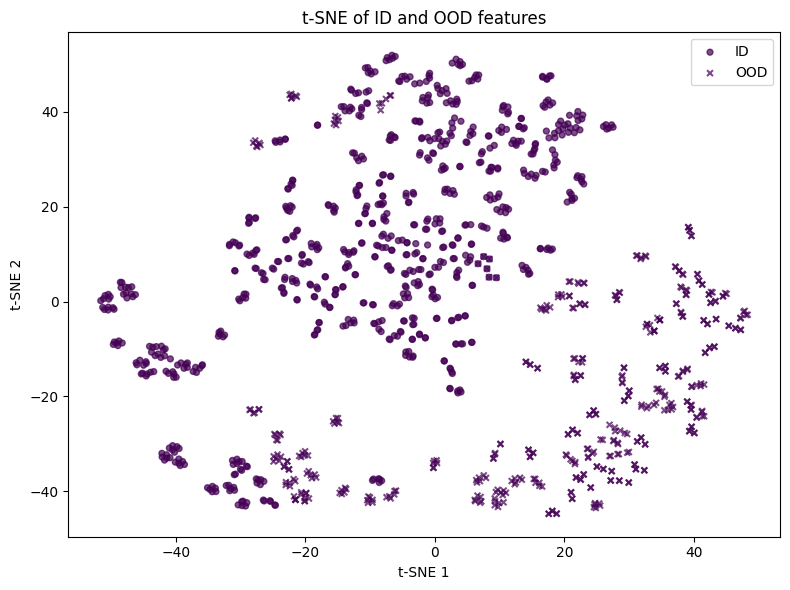

In [14]:
plt.figure(figsize=(8, 6))

# ID points
scatter_id = plt.scatter(
    X_tsne_id[:, 0],
    X_tsne_id[:, 1],
    c=y_id_plot,
    alpha=0.7,
    s=18,
    label="ID"
)

# OOD points
scatter_ood = plt.scatter(
    X_tsne_ood[:, 0],
    X_tsne_ood[:, 1],
    c=y_ood_plot,
    alpha=0.7,
    s=18,
    marker="x",
    label="OOD"
)

plt.title("t-SNE of ID and OOD features")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
print("ID stats:")
print("mean:", scores_id.mean().item())
print("std:", scores_id.std().item())
print("min:", scores_id.min().item())
print("max:", scores_id.max().item())


ID stats:
mean: 0.1439838409423828
std: 0.019745564088225365
min: 0.10081425309181213
max: 0.21627582609653473


In [20]:
print("OOD stats:")
print("mean:", scores_ood.mean().item())
print("std:", scores_ood.std().item())
print("min:", scores_ood.min().item())
print("max:", scores_ood.max().item())
print("median:", scores_ood.median().item())


OOD stats:
mean: 1.6010704040527344
std: 0.5691111087799072
min: 0.12713415920734406
max: 4.5059733390808105
median: 1.5959978103637695
